In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instrukcje
Zaimplementuj, wytrenuj i przetestuj model sieci neuronowej do klasyfikacji obrazów z zestawu danych CIFAR-10. Zestaw danych składa się z 60 000 kolorowych obrazów (32×32 piksele) podzielonych na 10 klas, w tym samochody, psy, statki i inne.

Wytyczne dotyczące modelu:
- Użyj warstw Conv2D, Dropout, Dense, MaxPooling2D i Flatten.
- Jeśli sieć zawiera więcej niż 10 warstw, użyj kernel_initializer, aby poprawić wydajność i zapobiec problemowi zanikającego gradientu.

Kryteria oceny:
Wydajność Twojego modelu będzie oceniana na podstawie końcowej dokładności danych testowych:
- Dokładność < 0,599 → 0 punktów
- 0,600 < Dokładność < 0,699 → 7 punktów
- 0,700 < Dokładność > 0,779 → 9 punktów
- 0,78 < Dokładność > 0,799 → 12 punktów
- Dokładność > 0,800 → 14 punktów

Wymagane wyniki (do uwzględnienia w raporcie):
- Wizualizacja architektury sieciowej
- Wyeksportowany plik modelu (`.keras`)
- Macierz pomyłek
- Wykres historii uczenia (krzywe dokładności/strat)
- Końcowa dokładność danych testowych
- Kod źródłowy
Moja praca



In [2]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test)=cifar10.load_data()

print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


 (50000, 32, 32, 3) -> Oznacza to 50 tysięcy obrazków, z których każdy ma 32x32 piksele, a każdy piksel ma 3 kolory (RGB).

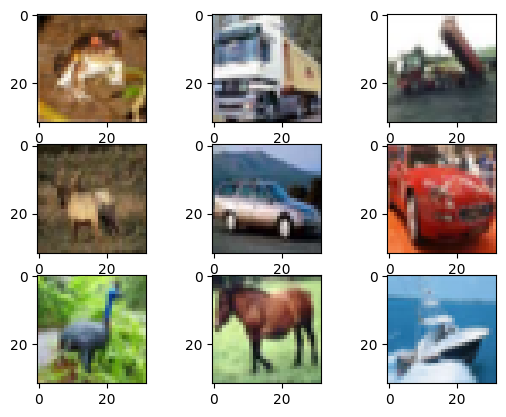

In [3]:
from matplotlib import pyplot

for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(x_train[i])
# show the figure
pyplot.show()

In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot

def load_dataset():
    # 1. Ładowanie danych
    (trainX, trainY), (testX, testY) = cifar10.load_data()

    # 2. One-hot encoding (zamiana etykiet 0-9 na wektory binarne)
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)

    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    # Konwersja na liczby zmiennoprzecinkowe i normalizacja do zakresu 0-1
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm

# Wywołanie funkcji
x_train, y_train, x_test, y_test = load_dataset()
x_train, x_test = prep_pixels(x_train, x_test)

print(f'Shape of x_train: {x_train.shape}')
print('Shape of y_train is {}'.format(y_train.shape))


Shape of x_train: (50000, 32, 32, 3)
Shape of y_train is (50000, 10)


# SGD

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych

    # Optymalizacja
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #trenowanie
    history = model.fit(trainX, trainY, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

    #ocena
    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    # Zapisywanie modelu
    model.save('/content/drive/MyDrive/Modele/model_sgd.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
  3/625 ━━━━━━━━━━━━━━━━━━━━ 8:34 828ms/step - accuracy: 0.0981 - loss: 3.8304

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

# SGD + argumentacja

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych


    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #argumentacja
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
    it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
    it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
    steps = int((trainX.shape[0] * 0.8) / 64)
    val_steps = int((trainX.shape[0] * 0.2) / 64)

    history = model.fit(it_train, steps_per_epoch=steps, epochs=100, batch_size=64, validation_data=it_val, validation_steps=val_steps, verbose=1)

    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    model.save('/content/drive/MyDrive/Modele/model_sgd_argumentacja.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

# SGD + argumentacja dalsze 200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator # DODANE: import generatora

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
steps = int((trainX.shape[0] * 0.8) / 64)
val_steps = int((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('/content/drive/MyDrive/Modele/model_sgd_argumentacja.keras')

# ZMIENIONE: Użycie generatora (it_train) i kroków (steps_per_epoch) zamiast surowych tablic trainX i trainY
history = model.fit(
    it_train,
    steps_per_epoch=steps,
    epochs=200,
    initial_epoch=100,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1
)


model.save('/content/drive/MyDrive/Modele/model_sgd_argumentacja_200epok.keras')

_, acc = model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

# SGD + argumentacja >200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # DODANE: import callbacków
import math # DODANE: import math dla ceil

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)

steps_per_epoch = math.ceil((trainX.shape[0] * 0.8) / 64)
val_steps = math.ceil((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('/content/drive/MyDrive/Modele/model_sgd_argumentacja_200epok.keras')

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=20, verbose=1)
mc = ModelCheckpoint('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja_best.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(
    it_train,
    steps_per_epoch=steps_per_epoch,
    epochs=300,
    initial_epoch=200,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1,
    callbacks=[es, mc] # DODANE: Callbacki do treningu
)

# Wczytanie najlepszego zapisanego modelu do oceny
saved_model = tf.keras.models.load_model('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja_best.keras')

_, acc = saved_model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

In [ ]:
import pydot
import graphviz

!pip install pydot
!apt-get install graphviz -y

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja_best.keras')


tf.keras.utils.plot_model(model, to_file='architektura.png', show_shapes=True, show_layer_names=True)

